In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.applications import vgg19
from IPython.display import Image, display
import matplotlib.pyplot as plt  
from tqdm import tqdm 


In [2]:

base_image_path = "clear.jpg"
style_reference_image_path = "written.jpg" 
result_prefix = "generated"

# Ваги різних компонентів втрат
total_variation_weight = 1e-6
style_weight = 1e-6
content_weight = 2.5e-8

# Розміри згенерованого зображення
width, height = keras.utils.load_img(base_image_path).size
img_nrows = 400
img_ncols = int(width * img_nrows / height)



def preprocess_image(image_path):
    # Функція для відкриття, зміни розміру та форматування зображень у тензори
    img = keras.utils.load_img(image_path, target_size=(img_nrows, img_ncols))
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = vgg19.preprocess_input(img)
    return tf.convert_to_tensor(img)

def deprocess_image(x):
    # Функція для перетворення тензора в зображення
    x = x.reshape((img_nrows, img_ncols, 3))
    # Відновлення центрування
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    # Перетворення 'BGR' -> 'RGB'
    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype("uint8")
    return x

# Матриця Грама для тензора
def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

# Функція втрат для стилю
def style_loss(style, combination):
    S = gram_matrix(style)
    C = gram_matrix(combination)
    channels = 3
    size = img_nrows * img_ncols
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels**2) * (size**2))

# Функція втрат для контенту
def content_loss(base, combination):
    return tf.reduce_sum(tf.square(combination - base))

# Функція total variation loss
def total_variation_loss(x):
    a = tf.square(
        x[:, : img_nrows - 1, : img_ncols - 1, :] - x[:, 1:, : img_ncols - 1, :]
    )
    b = tf.square(
        x[:, : img_nrows - 1, : img_ncols - 1, :] - x[:, : img_nrows - 1, 1:, :]
    )
    return tf.reduce_sum(tf.pow(a + b, 1.25))

# VGG19 з попередньо навченими вагами
model = vgg19.VGG19(weights="imagenet", include_top=False)

# Отримання виходів для кожного шару
outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

# Модель для отримання активацій
feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)

# Шари для втрат
style_layer_names = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]
content_layer_name = "block5_conv2"

def compute_loss(combination_image, base_image, style_reference_image):
    input_tensor = tf.concat(
        [base_image, style_reference_image, combination_image], axis=0
    )
    features = feature_extractor(input_tensor)

    loss = tf.zeros(shape=())

    layer_features = features[content_layer_name]
    base_image_features = layer_features[0, :, :, :]
    combination_features = layer_features[2, :, :, :]
    loss = loss + content_weight * content_loss(
        base_image_features, combination_features
    )

    for layer_name in style_layer_names:
        layer_features = features[layer_name]
        style_reference_features = layer_features[1, :, :, :]
        combination_features = layer_features[2, :, :, :]
        sl = style_loss(style_reference_features, combination_features)
        loss += (style_weight / len(style_layer_names)) * sl

    loss += total_variation_weight * total_variation_loss(combination_image)
    return loss

@tf.function
def compute_loss_and_grads(combination_image, base_image, style_reference_image):
    with tf.GradientTape() as tape:
        loss = compute_loss(combination_image, base_image, style_reference_image)
    grads = tape.gradient(loss, combination_image)
    return loss, grads

# Оптимізатор
optimizer = keras.optimizers.SGD(
    keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=100.0, decay_steps=100, decay_rate=0.96
    )
)

# Підготовка вхідних даних
base_image = preprocess_image(base_image_path)
style_reference_image = preprocess_image(style_reference_image_path)
combination_image = tf.Variable(preprocess_image(base_image_path))

iterations = 3000
losses_history = []

progress_bar = tqdm(range(1, iterations + 1), desc="Stylizing Image")

for i in progress_bar:
    loss, grads = compute_loss_and_grads(
        combination_image, base_image, style_reference_image
    )
    optimizer.apply_gradients([(grads, combination_image)])

    losses_history.append(loss.numpy())

    progress_bar.set_postfix({'loss': loss.numpy()})

    if i % 100 == 0:
         print(f"Iteration {i}/{iterations}, Total Loss: {loss.numpy()}")

Stylizing Image:   0%|                                                                        | 0/3000 [00:00<?, ?it/s]C:\Users\Vladyslav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor']. Received: the structure of inputs=*
  warnings.warn(
Stylizing Image:   3%|█▌                                            | 100/3000 [05:01<2:18:49,  2.87s/it, loss=2.56e+3]

Iteration 100/3000, Total Loss: 2560.819580078125


Stylizing Image:   7%|███                                           | 200/3000 [09:32<1:52:57,  2.42s/it, loss=2.24e+3]

Iteration 200/3000, Total Loss: 2236.908447265625


Stylizing Image:  10%|████▋                                          | 300/3000 [14:03<2:08:38,  2.86s/it, loss=2.1e+3]

...

Iteration 2800/3000, Total Loss: 1742.57373046875


Stylizing Image:  97%|███████████████████████████████████████████▌ | 2900/3000 [2:08:39<03:53,  2.33s/it, loss=1.74e+3]

Iteration 2900/3000, Total Loss: 1740.135498046875


Stylizing Image: 100%|█████████████████████████████████████████████| 3000/3000 [2:13:00<00:00,  2.66s/it, loss=1.74e+3]

Iteration 3000/3000, Total Loss: 1737.85546875


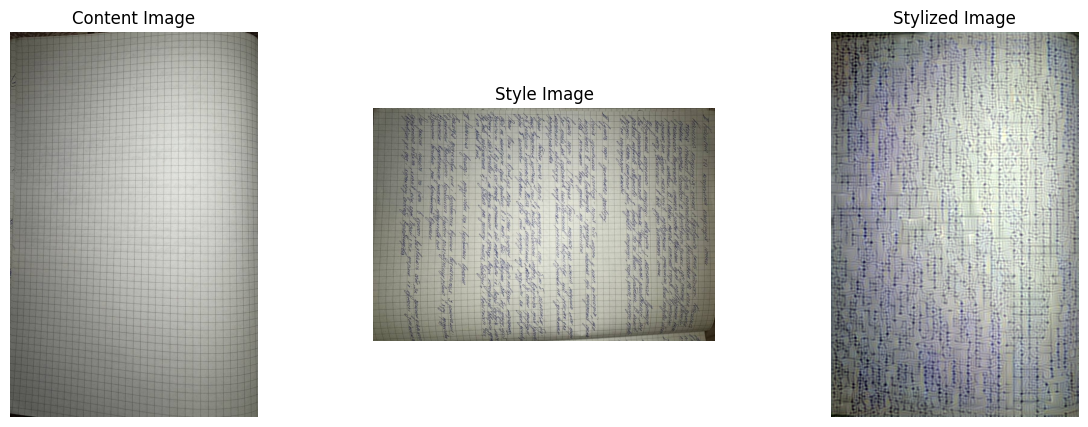

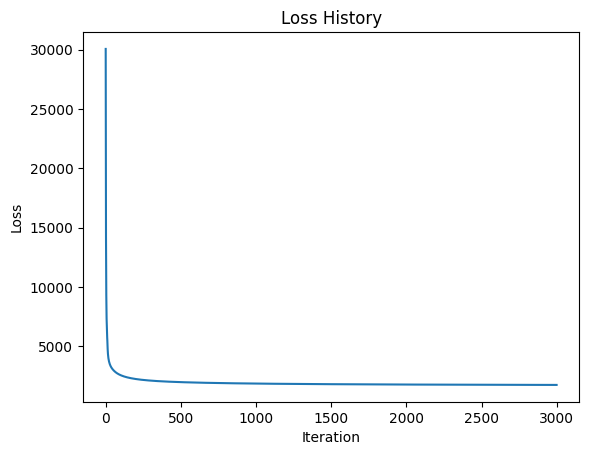

In [3]:
img = deprocess_image(combination_image.numpy())
fname = result_prefix + ".png"
keras.utils.save_img(fname, img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(keras.utils.load_img(base_image_path))
plt.title("Content Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(keras.utils.load_img(style_reference_image_path))
plt.title("Style Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img)
plt.title("Stylized Image")
plt.axis('off')

plt.show()

plt.plot(losses_history)
plt.title("Loss History")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()